 Dataset chargé : 149,434 lignes × 45 colonnes
 Features : ['flow_duration', 'flow_byts_s', 'flow_pkts_s', 'fwd_pkts_s', 'bwd_pkts_s', 'tot_fwd_pkts', 'tot_bwd_pkts', 'totlen_fwd_pkts', 'totlen_bwd_pkts', 'fwd_pkt_len_max', 'fwd_pkt_len_min', 'fwd_pkt_len_mean', 'fwd_pkt_len_std', 'bwd_pkt_len_max', 'bwd_pkt_len_min', 'bwd_pkt_len_mean', 'bwd_pkt_len_std', 'pkt_len_max', 'pkt_len_min', 'pkt_len_mean', 'pkt_len_std', 'pkt_len_var', 'fwd_header_len', 'bwd_header_len', 'fwd_seg_size_min', 'fwd_act_data_pkts', 'flow_iat_mean', 'flow_iat_max', 'flow_iat_min', 'flow_iat_std', 'fwd_iat_tot', 'fwd_iat_max', 'fwd_iat_min', 'fwd_iat_mean', 'fwd_iat_std', 'bwd_iat_tot', 'bwd_iat_max', 'bwd_iat_min', 'bwd_iat_mean', 'bwd_iat_std', 'pkt_size_avg', 'fwd_seg_size_avg', 'subflow_fwd_pkts', 'subflow_fwd_byts', 'label']
  Mapping M/C/P défini
 Dimension M : 11 features
 Dimension C : 18 features
 Dimension P : 15 features
 Ignorées    : 1 colonnes
 Tableau de mapping M/C/P — UAV-NIDD :

          Featur

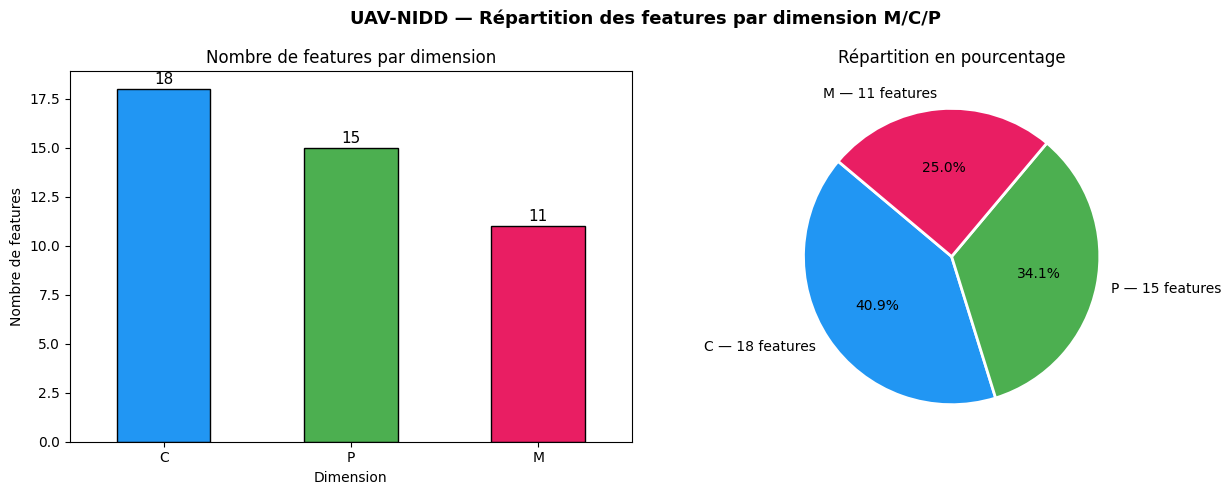

 Features M (11) : ['flow_byts_s', 'flow_pkts_s', 'fwd_pkts_s', 'bwd_pkts_s', 'tot_fwd_pkts', 'tot_bwd_pkts', 'totlen_fwd_pkts', 'totlen_bwd_pkts', 'fwd_act_data_pkts', 'subflow_fwd_pkts', 'subflow_fwd_byts']

  Features C (18) : ['fwd_pkt_len_max', 'fwd_pkt_len_min', 'fwd_pkt_len_mean', 'fwd_pkt_len_std', 'bwd_pkt_len_max', 'bwd_pkt_len_min', 'bwd_pkt_len_mean', 'bwd_pkt_len_std', 'pkt_len_max', 'pkt_len_min', 'pkt_len_mean', 'pkt_len_std', 'pkt_len_var', 'pkt_size_avg', 'fwd_header_len', 'bwd_header_len', 'fwd_seg_size_min', 'fwd_seg_size_avg']

  Features P (15) : ['flow_duration', 'flow_iat_mean', 'flow_iat_max', 'flow_iat_min', 'flow_iat_std', 'fwd_iat_tot', 'fwd_iat_max', 'fwd_iat_min', 'fwd_iat_mean', 'fwd_iat_std', 'bwd_iat_tot', 'bwd_iat_max', 'bwd_iat_min', 'bwd_iat_mean', 'bwd_iat_std']

 M présentes : 11/11
  C présentes : 18/18
  P présentes : 15/15
 Moyennes des features M par classe :

             flow_byts_s  flow_pkts_s  fwd_pkts_s  bwd_pkts_s  tot_fwd_pkts  tot_bwd_p

In [ ]:
# ============================================================
# NOTEBOOK : Mapping M/C/P — UAV-NIDD
# Dataset  : UAV Network Intrusion Detection Dataset
# ============================================================

# ────────────────────────────────────────
# 1. IMPORTATION DES LIBRAIRIES
# ────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# ────────────────────────────────────────
# 2. CHARGEMENT DU DATASET
# ────────────────────────────────────────
FILE_PATH = r"C:\Drone_Attack_Similarity_Project\DATASET\UAV_NIDD\Normal\Normal.csv"

if not os.path.exists(FILE_PATH):
    FILE_PATH = r"C:\Drone_Attack_Similarity_Project\DATASET\UAV_NIDD\Nomral+Attacks\Normal+Attacks11.csv"

df = pd.read_csv(FILE_PATH)
print(f" Dataset chargé : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
print(f" Features : {df.columns.tolist()}")

# ────────────────────────────────────────
# 3. DÉFINITION DU MAPPING M/C/P
# ────────────────────────────────────────

mapping_uavnidd = {

    # ── M : MÉCANISME D'ATTAQUE ──────────────────────────────
    # Features décrivant COMMENT l'attaque agit
    # (volume de trafic, injection, manipulation des paquets)

    'flow_byts_s'       : ('M', 'Débit en octets/s — élevé = mécanisme DDoS/DoS par inondation'),
    'flow_pkts_s'       : ('M', 'Débit en paquets/s — élevé = mécanisme d\'inondation réseau'),
    'fwd_pkts_s'        : ('M', 'Paquets envoyés/s — taux élevé = mécanisme attaque active'),
    'bwd_pkts_s'        : ('M', 'Paquets reçus/s — taux faible = mécanisme de suppression'),
    'tot_fwd_pkts'      : ('M', 'Total paquets forward — volume révèle l\'intensité de l\'attaque'),
    'tot_bwd_pkts'      : ('M', 'Total paquets backward — asymétrie révèle attaque unidirectionnelle'),
    'totlen_fwd_pkts'   : ('M', 'Volume total forward — grand volume = mécanisme Flooding'),
    'totlen_bwd_pkts'   : ('M', 'Volume total backward — faible = mécanisme de blocage'),
    'fwd_act_data_pkts' : ('M', 'Paquets actifs forward — nombre de paquets avec données réelles'),
    'subflow_fwd_pkts'  : ('M', 'Paquets sous-flux forward — mécanisme de fragmentation'),
    'subflow_fwd_byts'  : ('M', 'Octets sous-flux forward — volume de données injectées'),

    # ── C : COMPOSANT CIBLÉ ──────────────────────────────────
    # Features décrivant QUEL élément est affecté
    # (interface réseau, structure des paquets, headers)


    'fwd_pkt_len_max'   : ('C', 'Taille max paquet forward — composant structure des paquets'),
    'fwd_pkt_len_min'   : ('C', 'Taille min paquet forward — composant structure des paquets'),
    'fwd_pkt_len_mean'  : ('C', 'Taille moyenne paquet forward — composant taille nominale'),
    'fwd_pkt_len_std'   : ('C', 'Écart-type taille forward — composant variabilité des paquets'),
    'bwd_pkt_len_max'   : ('C', 'Taille max paquet backward — composant structure réponse'),
    'bwd_pkt_len_min'   : ('C', 'Taille min paquet backward — composant structure réponse'),
    'bwd_pkt_len_mean'  : ('C', 'Taille moyenne backward — composant taille nominale réponse'),
    'bwd_pkt_len_std'   : ('C', 'Écart-type taille backward — composant variabilité réponse'),
    'pkt_len_max'       : ('C', 'Taille max globale — composant capacité maximale du canal'),
    'pkt_len_min'       : ('C', 'Taille min globale — composant taille minimale transmise'),
    'pkt_len_mean'      : ('C', 'Taille moyenne globale — composant taille nominale du flux'),
    'pkt_len_std'       : ('C', 'Écart-type taille globale — composant variabilité du flux'),
    'pkt_len_var'       : ('C', 'Variance taille — composant irrégularité structurelle'),
    'pkt_size_avg'      : ('C', 'Taille moyenne des paquets — composant profil du trafic'),
    'fwd_header_len'    : ('C', 'Longueur header forward — composant couche réseau ciblée'),
    'bwd_header_len'    : ('C', 'Longueur header backward — composant couche réseau réponse'),
    'fwd_seg_size_min'  : ('C', 'Taille min segment forward — composant fragmentation TCP'),
    'fwd_seg_size_avg'  : ('C', 'Taille moyenne segment forward — composant segmentation'),

    # ── P : PARAMÈTRE D'EXÉCUTION ────────────────────────────
    # Features décrivant les VALEURS TEMPORELLES et STATISTIQUES
    # qui paramétrisent l'intensité et le timing de l'attaque

    'flow_duration'     : ('P', 'Durée totale du flux — paramètre temporel de l\'attaque'),
    'flow_iat_mean'     : ('P', 'Inter-arrivée moyenne — paramètre de fréquence d\'envoi'),
    'flow_iat_max'      : ('P', 'Inter-arrivée max — paramètre de pause maximale entre paquets'),
    'flow_iat_min'      : ('P', 'Inter-arrivée min — paramètre de rafale maximale'),
    'flow_iat_std'      : ('P', 'Écart-type inter-arrivée — paramètre de régularité du flux'),
    'fwd_iat_tot'       : ('P', 'Total inter-arrivée forward — paramètre durée totale émission'),
    'fwd_iat_max'       : ('P', 'Inter-arrivée max forward — paramètre pause max émission'),
    'fwd_iat_min'       : ('P', 'Inter-arrivée min forward — paramètre rafale max émission'),
    'fwd_iat_mean'      : ('P', 'Inter-arrivée moyenne forward — paramètre cadence d\'envoi'),
    'fwd_iat_std'       : ('P', 'Écart-type IAT forward — paramètre irrégularité émission'),
    'bwd_iat_tot'       : ('P', 'Total inter-arrivée backward — paramètre durée totale réception'),
    'bwd_iat_max'       : ('P', 'Inter-arrivée max backward — paramètre pause max réception'),
    'bwd_iat_min'       : ('P', 'Inter-arrivée min backward — paramètre rafale max réception'),
    'bwd_iat_mean'      : ('P', 'Inter-arrivée moyenne backward — paramètre cadence réception'),
    'bwd_iat_std'       : ('P', 'Écart-type IAT backward — paramètre irrégularité réception'),

    # ── IGNORÉE ───────────────────────────────────────────────
    'label'             : ('—', 'Label de classe — variable cible, pas une feature d\'attaque'),
}

print("  Mapping M/C/P défini")
print(f" Dimension M : {sum(1 for v in mapping_uavnidd.values() if v[0]=='M')} features")
print(f" Dimension C : {sum(1 for v in mapping_uavnidd.values() if v[0]=='C')} features")
print(f" Dimension P : {sum(1 for v in mapping_uavnidd.values() if v[0]=='P')} features")
print(f" Ignorées    : {sum(1 for v in mapping_uavnidd.values() if v[0]=='—')} colonnes")

# ────────────────────────────────────────
# 4. CRÉATION DU TABLEAU DE MAPPING
# ────────────────────────────────────────
rows = []
for feature, (dimension, justification) in mapping_uavnidd.items():
    rows.append({
        'Feature'      : feature,
        'Dimension'    : dimension,
        'Justification': justification
    })

mapping_df = pd.DataFrame(rows).sort_values('Dimension')

print(" Tableau de mapping M/C/P — UAV-NIDD :\n")
print(mapping_df.to_string(index=False))


# ────────────────────────────────────────
# 5. VISUALISATION DU MAPPING
# ────────────────────────────────────────
mapping_plot = mapping_df[mapping_df['Dimension'] != '—']
counts = mapping_plot['Dimension'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("UAV-NIDD — Répartition des features par dimension M/C/P",fontsize=13, fontweight='bold')

colors = {'M': '#E91E63', 'C': '#2196F3', 'P': '#4CAF50'}
color_list = [colors[d] for d in counts.index]

# Barplot
counts.plot(kind='bar', ax=axes[0], color=color_list,
            edgecolor='black', width=0.5)
axes[0].set_title("Nombre de features par dimension")
axes[0].set_xlabel("Dimension")
axes[0].set_ylabel("Nombre de features")
axes[0].tick_params(axis='x', rotation=0)
for bar, val in zip(axes[0].patches, counts.values):axes[0].text(bar.get_x() + bar.get_width() / 2,bar.get_height() + 0.1,str(val), ha='center', va='bottom', fontsize=11)

# Pie chart
axes[1].pie(counts.values,labels=[f"{d} — {v} features" for d, v in
                    zip(counts.index, counts.values)],
            autopct='%1.1f%%',
            colors=color_list,
            startangle=140,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title("Répartition en pourcentage")

plt.tight_layout()
plt.savefig("UAVNIDD_mapping_MCP.png", dpi=150, bbox_inches='tight')
plt.show()

# ────────────────────────────────────────
# 6. EXTRACTION DES FEATURES PAR DIMENSION
# ────────────────────────────────────────
features_M = mapping_plot[mapping_plot['Dimension'] == 'M']['Feature'].tolist()
features_C = mapping_plot[mapping_plot['Dimension'] == 'C']['Feature'].tolist()
features_P = mapping_plot[mapping_plot['Dimension'] == 'P']['Feature'].tolist()

print(f" Features M ({len(features_M)}) : {features_M}")
print(f"\n  Features C ({len(features_C)}) : {features_C}")
print(f"\n  Features P ({len(features_P)}) : {features_P}")

# Filtrer uniquement les colonnes présentes dans le dataset
features_M_ok = [f for f in features_M if f in df.columns]
features_C_ok = [f for f in features_C if f in df.columns]
features_P_ok = [f for f in features_P if f in df.columns]

print(f"\n M présentes : {len(features_M_ok)}/{len(features_M)}")
print(f"  C présentes : {len(features_C_ok)}/{len(features_C)}")
print(f"  P présentes : {len(features_P_ok)}/{len(features_P)}")

# ────────────────────────────────────────
# 7. STATISTIQUES PAR DIMENSION ET PAR CLASSE
# ────────────────────────────────────────
label_col = 'label' if 'label' in df.columns else 'label_encoded'

print(" Moyennes des features M par classe :\n")
if features_M_ok:
    print(df.groupby(label_col)[features_M_ok].mean().round(3).to_string())

print("\n Moyennes des features P par classe :\n")
if features_P_ok:
    print(df.groupby(label_col)[features_P_ok].mean().round(3).to_string())
